In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [12]:
random_seed = 42
lr = 0.001
batch_size = 64
epochs = 10
# num_classes will be determined from dataset

In [13]:
# Dataset Configuration - Change this to use different datasets
DATASET_NAME = "MNIST"  # Options: "MNIST", "CIFAR10", "CIFAR100", "FashionMNIST", "CelebA"

def get_dataset_config(dataset_name):
    """Configure dataset-specific parameters"""
    if dataset_name == "MNIST":
        return {
            'dataset': datasets.MNIST,
            'transform': transforms.Compose([transforms.ToTensor()]),
            'root': './data'
        }
    elif dataset_name == "FashionMNIST":
        return {
            'dataset': datasets.FashionMNIST,
            'transform': transforms.Compose([transforms.ToTensor()]),
            'root': './data'
        }
    elif dataset_name == "CIFAR10":
        return {
            'dataset': datasets.CIFAR10,
            'transform': transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ]),
            'root': './data'
        }
    elif dataset_name == "CIFAR100":
        return {
            'dataset': datasets.CIFAR100,
            'transform': transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ]),
            'root': './data'
        }
    elif dataset_name == "CelebA":
        return {
            'dataset': datasets.CelebA,
            'transform': transforms.Compose([
                transforms.CenterCrop(178),
                transforms.Resize((64, 64)),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ]),
            'root': './data'
        }
    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

dataset_config = get_dataset_config(DATASET_NAME)
print(f"Using dataset: {DATASET_NAME}")

Using dataset: MNIST


In [14]:
train_dataset = dataset_config['dataset'](
    root=dataset_config['root'], 
    train=True, 
    download=True, 
    transform=dataset_config['transform']
)
test_dataset = dataset_config['dataset'](
    root=dataset_config['root'], 
    train=False, 
    download=True, 
    transform=dataset_config['transform']
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Determine number of classes from dataset
num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")

# Get sample to determine input dimensions
sample_input = train_dataset[0][0]
input_channels = sample_input.shape[0]
input_height = sample_input.shape[1]
input_width = sample_input.shape[2]
print(f"Input shape: {input_channels}x{input_height}x{input_width}")

Number of classes: 10
Input shape: 1x28x28


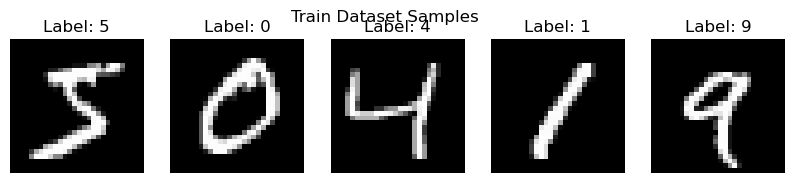

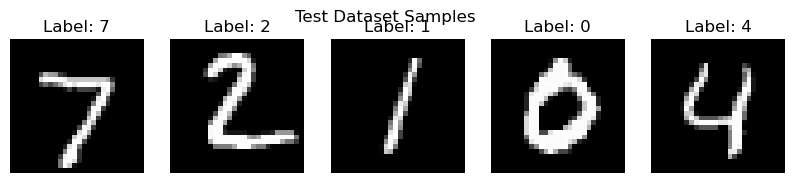

Train dataset size: 60000
Train dataset classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Size of each data sample in train_dataset: torch.Size([1, 28, 28])
Type of image: <class 'torch.Tensor'>, Type of label: <class 'int'>


In [15]:
def show_images(dataset, title, num_images=5):
    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        image, label = dataset[i]
        plt.subplot(1, num_images, i + 1)
        
        # Handle both grayscale and color images
        if image.shape[0] == 1:  # Grayscale image
            plt.imshow(image.squeeze(), cmap='gray')
        else:  # Color image (RGB)
            # Convert from CHW to HWC format for matplotlib
            img_display = image.permute(1, 2, 0)
            # Denormalize if needed (for CIFAR datasets)
            if img_display.min() < 0:
                img_display = (img_display + 1) / 2  # Convert from [-1,1] to [0,1]
            plt.imshow(img_display.clamp(0, 1))
        
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(train_dataset, 'Train Dataset Samples')
show_images(test_dataset, 'Test Dataset Samples')

print(f'Train dataset size: {len(train_dataset)}')
print(f'Train dataset classes: {train_dataset.classes}')
# Each item in the dataset is a tuple: (image, label)
# image: torch.Tensor of shape [channels, height, width]
# label: int (class index)
print(f'Size of each data sample in train_dataset: {train_dataset[0][0].shape}')
print(f'Type of image: {type(train_dataset[0][0])}, Type of label: {type(train_dataset[0][1])}')

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
class Quantizer(nn.Module):
    def __init__(self, in_dim, embed_dim, codebook_size=512, beta=0.25):
        super().__init__()
        self.in_dim = in_dim  # Number of input channels (64 from encoder)
        self.embed_dim = embed_dim  # Embedding dimension for codebook
        self.beta = beta
        self.codebook_size = codebook_size

        # VQ-VAE codebook
        self.codebook_embedding = nn.Embedding(self.codebook_size, embed_dim)
        self.codebook_embedding.weight.data.uniform_(-1.0 / self.codebook_size, 1.0 / self.codebook_size)

        # Project input to embedding dimension if different
        if in_dim != embed_dim:
            self.proj_in = nn.Conv2d(in_dim, embed_dim, 1)
            self.proj_out = nn.Conv2d(embed_dim, in_dim, 1)
        else:
            self.proj_in = nn.Identity()
            self.proj_out = nn.Identity()

    def forward(self, z_e):
        B, D, H, W = z_e.shape
        
        # Project to embedding dimension
        z_e_proj = self.proj_in(z_e)
        embed_dim = z_e_proj.shape[1]

        # Reshape z_e: [B, embed_dim, H, W] -> [B*H*W, embed_dim]
        z_e_flat = z_e_proj.permute(0, 2, 3, 1).reshape(-1, embed_dim)

        # Compute L2 distance between each z_e and all codebook embeddings
        # distances: [BHW, K]
        dist = (
            torch.sum(z_e_flat ** 2, dim=1, keepdim=True)
            + torch.sum(self.codebook_embedding.weight ** 2, dim=1)
            - 2 * torch.matmul(z_e_flat, self.codebook_embedding.weight.t())
        )

        # Get nearest codebook entry for each encoder output
        indices = torch.argmin(dist, dim=1)  # [BHW]
        z_q_flat = self.codebook_embedding(indices)   # [BHW, embed_dim]

        # Reshape back to [B, embed_dim, H, W]
        z_q = z_q_flat.view(B, H, W, embed_dim).permute(0, 3, 1, 2)
        
        # Project back to input dimension
        z_q_out = self.proj_out(z_q)

        # Now compute losses (use projected versions)
        commitment_loss = F.mse_loss(z_e_proj.detach(), z_q)
        codebook_loss = F.mse_loss(z_q.detach(), z_e_proj)
        loss = codebook_loss + commitment_loss * self.beta

        # Straight-through estimator: pass gradients from decoder to encoder
        z_q_final = z_e + (z_q_out - z_e).detach()  # Straight-through estimator

        return z_q_final, loss, indices


class VQVariationalAutoEncoder(nn.Module):
    def __init__(self, input_channels=1, input_height=28, input_width=28, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_channels = input_channels
        self.input_height = input_height
        self.input_width = input_width
        
        # Calculate dimensions after convolutions
        # After 2 MaxPool2d operations: height/4, width/4
        self.conv_height = input_height // 4
        self.conv_width = input_width // 4

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=3, padding=1),  # [B, input_channels, H, W] -> [B, 16, H, W]
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # [B, 16, H, W] -> [B, 16, H/2, W/2]

            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # [B, 16, H/2, W/2] -> [B, 32, H/2, W/2]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # [B, 32, H/2, W/2] -> [B, 32, H/4, W/4]

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [B, 32, H/4, W/4] -> [B, 64, H/4, W/4]
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Quantizer takes 64 channels and projects to latent_dim for codebook lookup
        self.quantizer = Quantizer(in_dim=64, embed_dim=latent_dim)  

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # [B, 64, H/4, W/4] -> [B, 32, H/2, W/2]
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # [B, 32, H/2, W/2] -> [B, 16, H, W]
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, input_channels, kernel_size=3, padding=1),  # [B, 16, H, W] -> [B, input_channels, H, W]
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x_q, q_loss, _ = self.quantizer(x)
        out = self.decoder(x_q)
        return out, q_loss

    def get_latents(self, x):
        x = self.encoder(x)
        x_q, q_loss, _ = self.quantizer(x)
        return x_q

In [25]:
model = VQVariationalAutoEncoder(
    input_channels=input_channels,
    input_height=input_height,
    input_width=input_width,
    latent_dim=64
).to(device)
print(model)

VQVariationalAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (quantizer): Quantizer(
    (codebook_embedding): Embedding(512, 64)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_

In [26]:
from IPython.display import clear_output

def plot_losses(training_losses, test_losses):
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.plot(training_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Losses')
    plt.legend()
    plt.grid(True)
    plt.show()



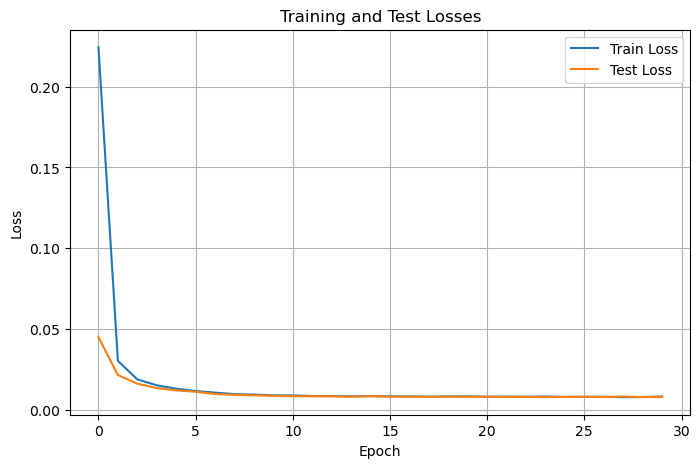

In [27]:
torch.manual_seed(random_seed)

num_epochs = 30
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

test_losses = []
training_losses = []

for epoch in range(num_epochs):
    model.train()
    batch_losses = []
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        output, q_loss = model(data)
        loss = criterion(output, data) + q_loss  # Combine reconstruction loss and quantization loss

        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            batch_losses.append(loss.item())
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    avg_loss = np.mean(batch_losses)
    print(f'Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    training_losses.append(avg_loss)

    # Evaluate test loss
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            output, q_loss = model(data)
            loss = criterion(output, data) + q_loss  # Combine reconstruction loss and quantization loss
            test_loss += loss.item() * data.size(0)
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] Test Loss: {test_loss:.4f}')

    plot_losses(training_losses, test_losses)

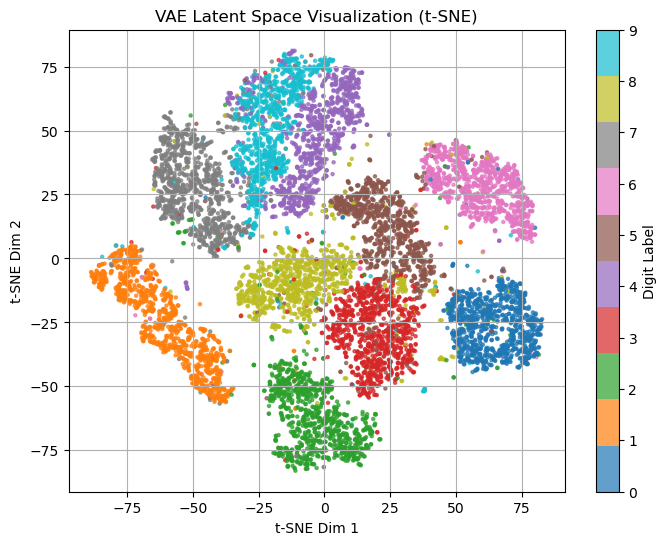

In [35]:
from sklearn.manifold import TSNE

# Collect latent vectors and labels from test set
model.eval()
latents = []
labels = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        # Pass through encoder and bottleneck only
        latent = model.get_latents(data).flatten(1)
        latent = latent.cpu().numpy()
        latents.append(latent)
        labels.append(target.numpy())

latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

# Run t-SNE
tsne = TSNE(n_components=2, random_state=random_seed)
latents_2d = tsne.fit_transform(latents)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, ticks=range(num_classes), label='Digit Label')
plt.title('VAE Latent Space Visualization (t-SNE)')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.grid(True)
plt.show()

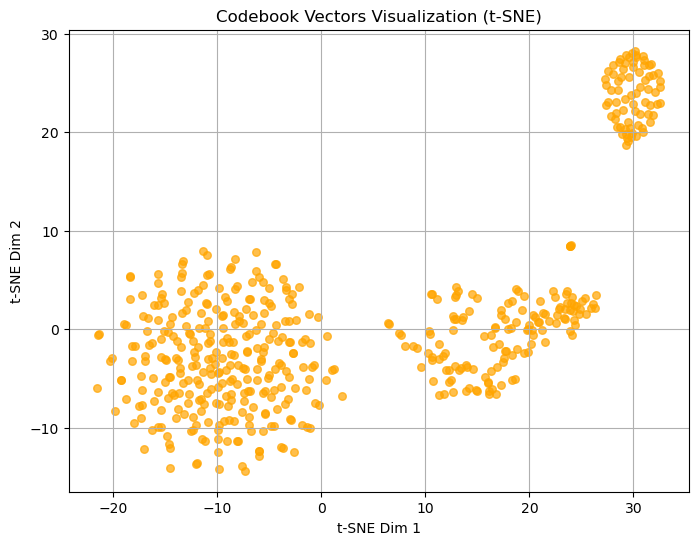

In [48]:
from sklearn.manifold import TSNE

# Visualize codebook vectors using t-SNE
codebook_vectors = model.quantizer.codebook_embedding.weight.detach().cpu().numpy()

tsne_codebook = TSNE(n_components=2, random_state=random_seed)
codebook_2d = tsne_codebook.fit_transform(codebook_vectors)

plt.figure(figsize=(8, 6))
plt.scatter(codebook_2d[:, 0], codebook_2d[:, 1], s=30, c='orange', alpha=0.7)
plt.title('Codebook Vectors Visualization (t-SNE)')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.grid(True)
plt.show()

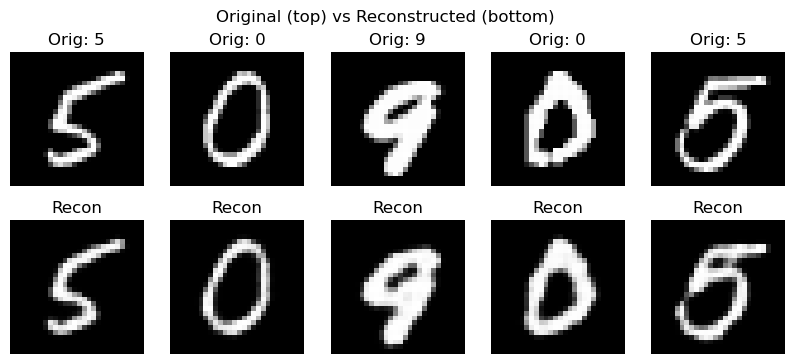

In [75]:
indices = np.random.choice(len(test_dataset), size=5, replace=False)
sample_images = [test_dataset[i][0] for i in indices]
sample_labels = [test_dataset[i][1] for i in indices]

def display_image(img, ax, title):
    """Helper function to display image regardless of color/grayscale"""
    if img.shape[0] == 1:  # Grayscale
        ax.imshow(img.squeeze(), cmap='gray')
    else:  # Color
        img_display = img.permute(1, 2, 0)
        if img_display.min() < 0:
            img_display = (img_display + 1) / 2
        ax.imshow(img_display.clamp(0, 1))
    ax.set_title(title)
    ax.axis('off')

with torch.no_grad():
    batch = torch.stack(sample_images).to(device)
    reconstructed, _ = model(batch)

    plt.figure(figsize=(10, 4))
    for i in range(5):
        # Original image
        ax1 = plt.subplot(2, 5, i + 1)
        display_image(batch[i].cpu(), ax1, f'Orig: {sample_labels[i]}')
        
        # Reconstructed image
        ax2 = plt.subplot(2, 5, i + 6)
        display_image(reconstructed[i].cpu(), ax2, 'Recon')
        
    plt.suptitle('Original (top) vs Reconstructed (bottom)')
    plt.show()


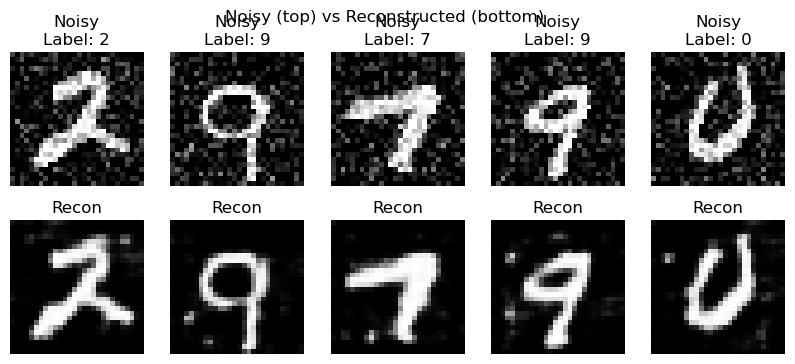

In [54]:
# Noisy reconstruction.
# Strangely, the VQ-VAE hasn't been trained to handle noise, but this still works.

indices = np.random.choice(len(test_dataset), size=5, replace=False)
sample_images = [test_dataset[i][0] for i in indices]
sample_labels = [test_dataset[i][1] for i in indices]

# Add Gaussian noise to each image
noisy_images = []
for img in sample_images:
    noise = torch.randn_like(img) * 0.2  # adjust stddev as needed
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, 0, 1)
    noisy_images.append(noisy_img)

with torch.no_grad():
    batch = torch.stack(noisy_images).to(device)
    reconstructed, _ = model(batch)

    plt.figure(figsize=(10, 4))
    for i in range(5):
        # Noisy image
        ax1 = plt.subplot(2, 5, i + 1)
        display_image(batch[i].cpu(), ax1, f'Noisy\nLabel: {sample_labels[i]}')
        
        # Reconstructed image
        ax2 = plt.subplot(2, 5, i + 6)
        display_image(reconstructed[i].cpu(), ax2, 'Recon')
        
    plt.suptitle('Noisy (top) vs Reconstructed (bottom)')
    plt.show()


torch.Size([1, 28, 28]) torch.Size([1, 28, 28])
torch.Size([2, 64, 7, 7])


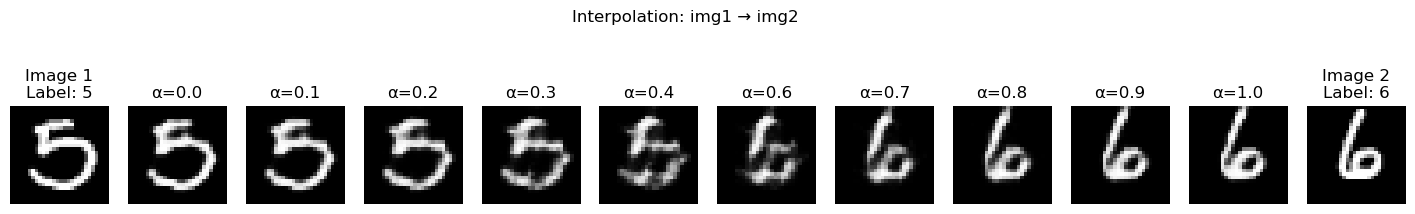

In [56]:
label1, label2 = 0, 0

while label1 == label2:
    indices = np.random.choice(len(test_dataset), size=2, replace=False)
    sample_images = [test_dataset[i][0] for i in indices]
    sample_labels = [test_dataset[i][1] for i in indices]
    img1, img2 = sample_images
    label1, label2 = sample_labels

print(img1.shape, img2.shape)

# Convert images to latent vectors z1,z2
z = model.get_latents(torch.stack([img1, img2]).to(device))
print(z.shape)
z1 = z[0].cpu()
z2 = z[1].cpu()

with torch.no_grad():
    alphas = np.linspace(0, 1, 10)
    interpolated_latents = [a * z2 + (1 - a) * z1 for a in alphas]
    with torch.no_grad():
        recons = model.decoder(torch.stack(interpolated_latents).to(device))
        recons = recons.cpu()

    plt.figure(figsize=(18, 3))
    # Draw img1
    ax1 = plt.subplot(1, len(alphas) + 2, 1)
    display_image(img1.cpu(), ax1, f'Image 1\nLabel: {label1}')

    # Draw reconstructions
    for i, (a, recon) in enumerate(zip(alphas, recons)):
        ax = plt.subplot(1, len(alphas) + 2, i + 2)
        display_image(recon, ax, f'α={a:.1f}')

    # Draw img2
    ax2 = plt.subplot(1, len(alphas) + 2, len(alphas) + 2)
    display_image(img2.cpu(), ax2, f'Image 2\nLabel: {label2}')

    plt.suptitle('Interpolation: img1 → img2')
    plt.show()

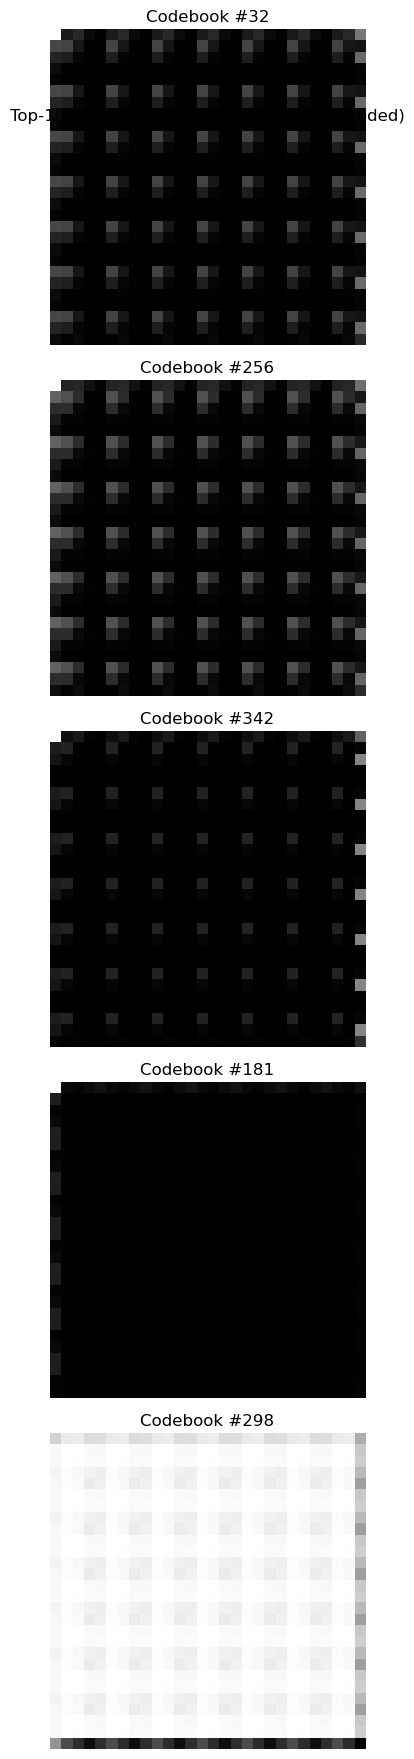

In [70]:
from collections import Counter

# Get codebook usage statistics on the test set
model.eval()
all_indices = []

with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)
        # Pass through encoder and quantizer only
        x = model.encoder(data)
        _, _, indices = model.quantizer(x)
        # indices: [batch_size * H * W]
        all_indices.append(indices.cpu().numpy())

all_indices = np.concatenate(all_indices)
# Count frequency of each codebook index
counter = Counter(all_indices)
top_10 = counter.most_common(5)
top_10_indices = [idx for idx, _ in top_10]


with torch.no_grad():
    # Decode each codebook vector to image
    decoded_images = []
    for idx in top_10_indices:
        # Get codebook vector
        code_vec = model.quantizer.codebook_embedding.weight[idx].detach().to(device)
        # Create a feature map with this codebook vector tiled spatially
        # Shape: [1, embed_dim, conv_height, conv_width]
        tiled = code_vec.view(1, -1, 1, 1).expand(1, model.latent_dim, model.conv_height, model.conv_width)
        
        # If we have projection layers, we need to go through proj_out first
        if hasattr(model.quantizer, 'proj_out') and not isinstance(model.quantizer.proj_out, nn.Identity):
            tiled = model.quantizer.proj_out(tiled)
        
        # Pass through decoder
        recon = model.decoder(tiled).cpu().squeeze(0)
        decoded_images.append(recon)

# Display decoded images, each in a separate row for larger size
plt.figure(figsize=(6, 18))
for i, img in enumerate(decoded_images):
    ax = plt.subplot(len(decoded_images), 1, i + 1)
    display_image(img, ax, f'Codebook #{top_10_indices[i]}')
plt.suptitle('Top-10 Most Used Codebook Vectors (Decoded)', y=0.92)
plt.tight_layout()
plt.show()